# Real-Time Bidding Auction Prediction

## Problem Overview
This project aims to predict which auctions in real-time bidding (RTB) will lead to a sale. The goal is to reduce computational and networking costs by avoiding auctions that are unlikely to result in sales.

**Evaluation Metric**: Mean F1-Score

**Business Impact**: By accurately predicting unsuccessful auctions, Teads SSP can significantly reduce infrastructure costs while maintaining revenue from successful auctions.

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## Data Loading and Initial Exploration

Let's load the datasets and examine their structure.

In [23]:
# Load the datasets
print("Loading datasets...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_sample = pd.read_csv('testSubmissionFile.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Submission sample shape: {submission_sample.shape}")

# Display first few rows
print("\nFirst 5 rows of training data:")
print(train_df.head())

Loading datasets...
Training data shape: (967332, 14)
Test data shape: (242171, 13)
Submission sample shape: (242171, 2)

First 5 rows of training data:
                                           auctionId   timeStamp  placementId  \
0  001ed16b-dd08-4599-b8ef-4f56a373c454_6e5f1087-...  1603815466       120706   
1               0024b36a-4fb5-4070-88fb-fc0bfb1909ed  1603974586        69454   
2  003630fa-ad63-4283-be1b-141670132d70_f37c2b23-...  1604229969       100170   
3               0048c65a-ce76-43ba-98d2-8e87607468f8  1604156610       100446   
4               0056b8a7-54f9-4ac8-8d50-f725bf377872  1604004493       119517   

   websiteId                             hashedRefererDeepThree country  \
0      68203  1ae7c2d3c28b711c072d8e2eb3869fa59090669bdc153e...      US   
1      42543  df1108bf6ae49dbccf5eab60ff9d04a6a09dda60ec7290...      RO   
2      57703  cc6957e8aec85a4d920991c53874c5d0780bbfbd469802...      UK   
3      57797  7fc0bb7a65d074e003cce786cda2b070f80dd47179c4b9

In [24]:
# Data info and basic statistics
print("Training Data Info:")
print(train_df.info())

print("\nTraining Data Description:")
print(train_df.describe())

print("\nTarget variable distribution:")
print(train_df['isSold'].value_counts())
print(f"\nTarget variable balance: {train_df['isSold'].mean():.4f} (proportion of sold auctions)")

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967332 entries, 0 to 967331
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   auctionId                      967332 non-null  object
 1   timeStamp                      967332 non-null  int64 
 2   placementId                    967332 non-null  int64 
 3   websiteId                      967332 non-null  int64 
 4   hashedRefererDeepThree         951349 non-null  object
 5   country                        966900 non-null  object
 6   opeartingSystem                967332 non-null  object
 7   browser                        967332 non-null  object
 8   browserVersion                 837388 non-null  object
 9   device                         967332 non-null  object
 10  environmentType                967328 non-null  object
 11  integrationType                967332 non-null  int64 
 12  articleSafenessCategoriz

## Exploratory Data Analysis (EDA)

Let's explore the data to understand patterns and relationships.

In [14]:
# Check for missing values
print("Missing values in training data:")
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing values in test data:")
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0])

# Check data types
print("\nData types:")
print(train_df.dtypes)

Missing values in training data:
hashedRefererDeepThree     15983
country                      432
browserVersion            129944
environmentType                4
dtype: int64

Missing values in test data:
hashedRefererDeepThree     3860
country                     108
browserVersion            32387
environmentType               1
dtype: int64

Data types:
auctionId                        object
timeStamp                         int64
placementId                       int64
websiteId                         int64
hashedRefererDeepThree           object
country                          object
opeartingSystem                  object
browser                          object
browserVersion                   object
device                           object
environmentType                  object
integrationType                   int64
articleSafenessCategorization    object
isSold                             bool
dtype: object
hashedRefererDeepThree     15983
country                      43

KeyError: 'operatingSystem'

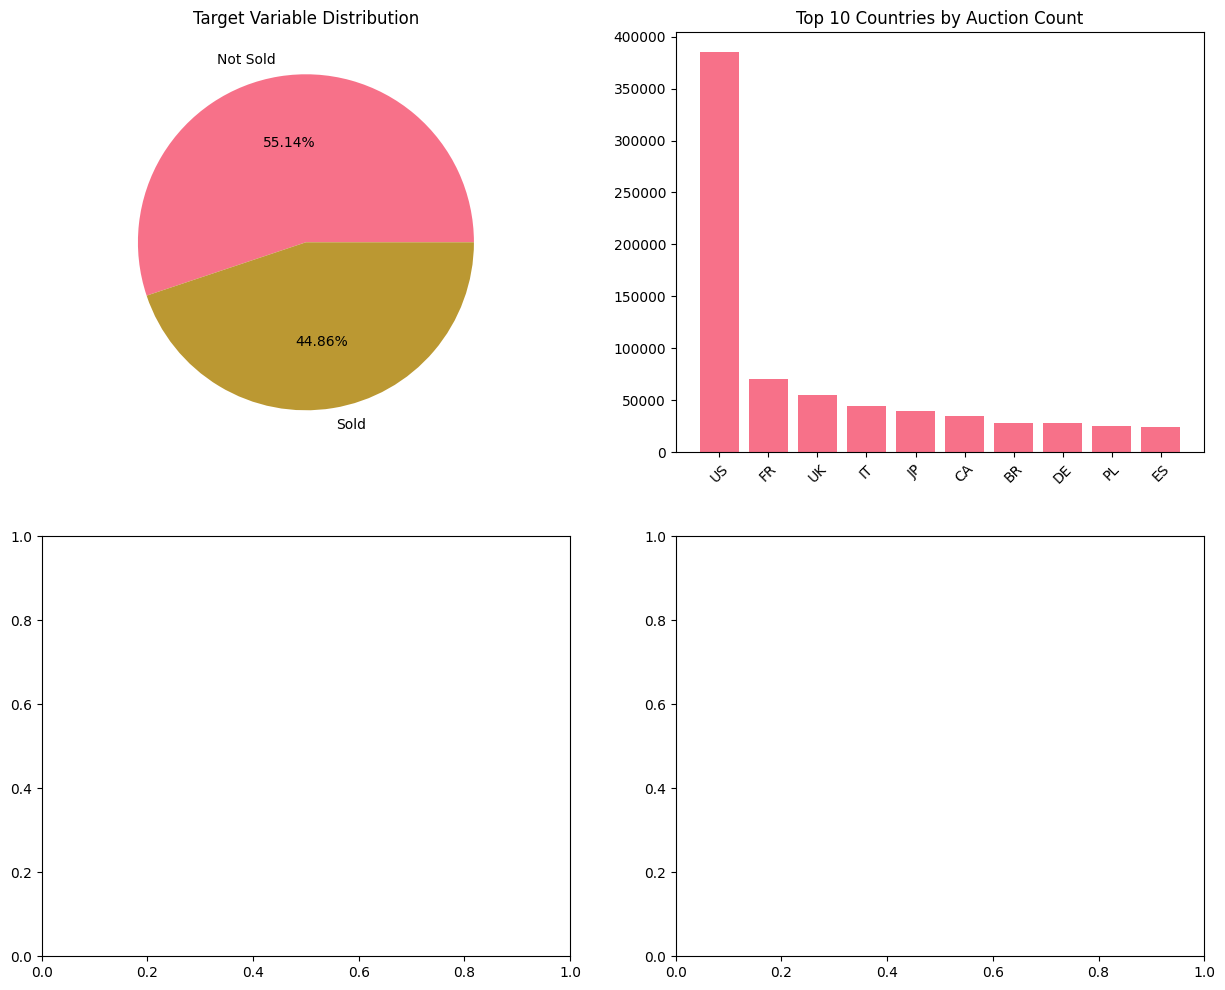

In [15]:
# Target variable distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Target distribution
axes[0,0].pie(train_df['isSold'].value_counts(), labels=['Not Sold', 'Sold'], autopct='%1.2f%%')
axes[0,0].set_title('Target Variable Distribution')

# Country distribution (top 10)
top_countries = train_df['country'].value_counts().head(10)
axes[0,1].bar(range(len(top_countries)), top_countries.values)
axes[0,1].set_title('Top 10 Countries by Auction Count')
axes[0,1].set_xticks(range(len(top_countries)))
axes[0,1].set_xticklabels(top_countries.index, rotation=45)

# Operating system distribution
os_dist = train_df['operatingSystem'].value_counts().head(8)
axes[1,0].bar(range(len(os_dist)), os_dist.values)
axes[1,0].set_title('Operating System Distribution')
axes[1,0].set_xticks(range(len(os_dist)))
axes[1,0].set_xticklabels(os_dist.index, rotation=45)

# Device type distribution
device_dist = train_df['device'].value_counts()
axes[1,1].pie(device_dist.values, labels=device_dist.index, autopct='%1.1f%%')
axes[1,1].set_title('Device Type Distribution')

plt.tight_layout()
plt.show()

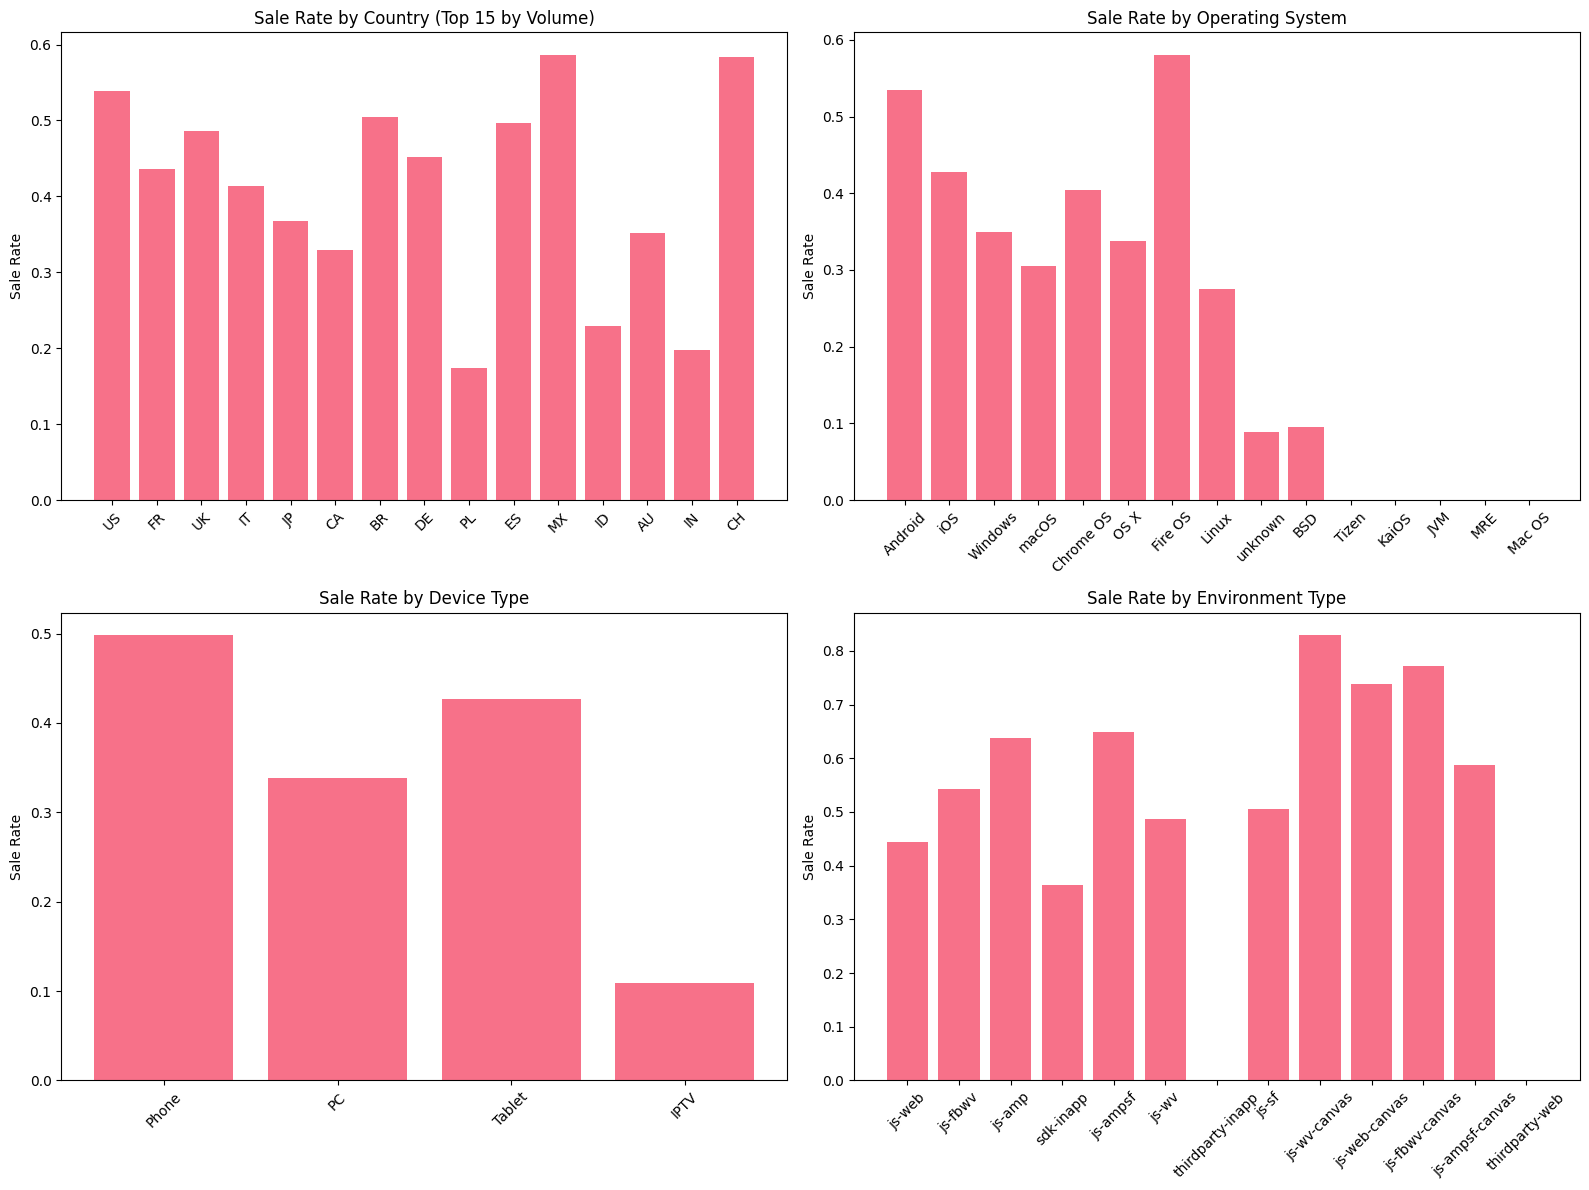

In [ ]:
# Analyze sale rates by different categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sale rate by country (top 15)
country_sales = train_df.groupby('country')['isSold'].agg(['count', 'mean']).sort_values('count', ascending=False).head(15)
axes[0,0].bar(range(len(country_sales)), country_sales['mean'])
axes[0,0].set_title('Sale Rate by Country (Top 15 by Volume)')
axes[0,0].set_ylabel('Sale Rate')
axes[0,0].set_xticks(range(len(country_sales)))
axes[0,0].set_xticklabels(country_sales.index, rotation=45)

# Sale rate by operating system
os_sales = train_df.groupby('operatingSystem')['isSold'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[0,1].bar(range(len(os_sales)), os_sales['mean'])
axes[0,1].set_title('Sale Rate by Operating System')
axes[0,1].set_ylabel('Sale Rate')
axes[0,1].set_xticks(range(len(os_sales)))
axes[0,1].set_xticklabels(os_sales.index, rotation=45)

# Sale rate by device
device_sales = train_df.groupby('device')['isSold'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[1,0].bar(range(len(device_sales)), device_sales['mean'])
axes[1,0].set_title('Sale Rate by Device Type')
axes[1,0].set_ylabel('Sale Rate')
axes[1,0].set_xticks(range(len(device_sales)))
axes[1,0].set_xticklabels(device_sales.index, rotation=45)

# Sale rate by environment type
env_sales = train_df.groupby('environmentType')['isSold'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[1,1].bar(range(len(env_sales)), env_sales['mean'])
axes[1,1].set_title('Sale Rate by Environment Type')
axes[1,1].set_ylabel('Sale Rate')
axes[1,1].set_xticks(range(len(env_sales)))
axes[1,1].set_xticklabels(env_sales.index, rotation=45)

plt.tight_layout()
plt.show()

## Feature Engineering

We'll create new features and encode categorical variables to improve model performance.

In [ ]:
def feature_engineering(df, is_train=True):
    """
    Perform feature engineering on the dataset
    """
    df_processed = df.copy()
    
    # Time-based features
    df_processed['hour'] = (df_processed['timeStamp'] // 3600) % 24
    df_processed['day_of_week'] = (df_processed['timeStamp'] // 86400) % 7
    
    # Browser version features
    df_processed['browser_major_version'] = df_processed['browserVersion'].str.split('_').str[0]
    df_processed['browser_minor_version'] = df_processed['browserVersion'].str.split('_').str[1]
    
    # Integration type features
    df_processed['integration_main'] = df_processed['integrationType'].astype(str)
    
    # Article safety as binary
    df_processed['is_article_safe'] = (df_processed['articleSafenessCategorization'] == 'safe').astype(int)
    
    return df_processed

# Apply feature engineering
print("Applying feature engineering...")
train_processed = feature_engineering(train_df, is_train=True)
test_processed = feature_engineering(test_df, is_train=False)

print(f"Processed training data shape: {train_processed.shape}")
print(f"Processed test data shape: {test_processed.shape}")

Applying feature engineering...
Processed training data shape: (967332, 20)
Processed test data shape: (242171, 19)
Processed training data shape: (967332, 20)
Processed test data shape: (242171, 19)


In [16]:
# Identify categorical columns
categorical_cols = ['country', 'operatingSystem', 'browser', 'device', 'environmentType', 
                   'integrationType', 'articleSafenessCategorization', 'browser_major_version']

# Label encode categorical variables - optimized for large datasets
label_encoders = {}
print("Starting categorical encoding...")

for col in categorical_cols:
    if col in train_processed.columns:
        print(f"Encoding {col}...")
        le = LabelEncoder()
        
        # Fit on training data
        train_processed[col + '_encoded'] = le.fit_transform(train_processed[col].astype(str))
        
        # Transform test data efficiently, handling unseen categories
        test_col_values = test_processed[col].astype(str)
        
        # Create a mapping for faster lookup
        class_to_idx = {cls: idx for idx, cls in enumerate(le.classes_)}
        
        # Vectorized transformation with unseen category handling
        test_encoded = [class_to_idx.get(val, -1) for val in test_col_values]
        test_processed[col + '_encoded'] = test_encoded
        
        label_encoders[col] = le
        print(f"  - Training unique values: {len(le.classes_)}")
        print(f"  - Test unseen values: {sum(1 for x in test_encoded if x == -1)}")

print("Categorical encoding completed.")
print(f"Encoded columns: {[col + '_encoded' for col in categorical_cols if col in train_processed.columns]}")

Starting categorical encoding...
Encoding country...
  - Training unique values: 216
  - Test unseen values: 2
Encoding browser...
  - Training unique values: 216
  - Test unseen values: 2
Encoding browser...
  - Training unique values: 121
  - Test unseen values: 0
Encoding device...
  - Training unique values: 121
  - Test unseen values: 0
Encoding device...
  - Training unique values: 4
  - Test unseen values: 0
Encoding environmentType...
  - Training unique values: 4
  - Test unseen values: 0
Encoding environmentType...
  - Training unique values: 14
  - Test unseen values: 0
Encoding integrationType...
  - Training unique values: 14
  - Test unseen values: 0
Encoding integrationType...
  - Training unique values: 2
  - Test unseen values: 0
Encoding articleSafenessCategorization...
  - Training unique values: 2
  - Test unseen values: 0
Encoding articleSafenessCategorization...
  - Training unique values: 3
  - Test unseen values: 0
Encoding browser_major_version...
  - Training 

In [17]:
# Select features for modeling
feature_cols = ['timeStamp', 'placementId', 'websiteId', 'hour', 'day_of_week', 
               'is_article_safe'] + [col + '_encoded' for col in categorical_cols if col in train_processed.columns]

# Remove non-numeric columns and prepare final datasets
X_train = train_processed[feature_cols].copy()
y_train = train_processed['isSold'].copy()
X_test = test_processed[feature_cols].copy()

# Handle any remaining missing values
X_train = X_train.fillna(-1)
X_test = X_test.fillna(-1)

print(f"Final feature matrix shape - Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features used: {feature_cols}")
print(f"\nTarget distribution:")
print(y_train.value_counts(normalize=True))

Final feature matrix shape - Train: (967332, 13), Test: (242171, 13)
Features used: ['timeStamp', 'placementId', 'websiteId', 'hour', 'day_of_week', 'is_article_safe', 'country_encoded', 'browser_encoded', 'device_encoded', 'environmentType_encoded', 'integrationType_encoded', 'articleSafenessCategorization_encoded', 'browser_major_version_encoded']

Target distribution:
isSold
False    0.551439
True     0.448561
Name: proportion, dtype: float64


## Model Development and Training

We'll train multiple models and use cross-validation to select the best approach. Since the evaluation metric is F1-score, we'll focus on optimizing for this metric.

In [25]:
# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")

# Define models to try
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate models
model_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_split, y_train_split)
    
    # Predictions
    y_pred = model.predict(X_val_split)
    
    # Calculate F1 score
    f1 = f1_score(y_val_split, y_pred)
    model_results[name] = {'model': model, 'f1_score': f1}
    
    print(f"{name} F1 Score: {f1:.4f}")
    print(f"Classification Report:")
    print(classification_report(y_val_split, y_pred))

# Find best model
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['f1_score'])
best_model = model_results[best_model_name]['model']
best_f1 = model_results[best_model_name]['f1_score']

print(f"\nBest Model: {best_model_name} with F1 Score: {best_f1:.4f}")

Training set: (773865, 13)
Validation set: (193467, 13)

Training Logistic Regression...
Logistic Regression F1 Score: 0.2159
Classification Report:
              precision    recall  f1-score   support

       False       0.56      0.90      0.69    106685
        True       0.54      0.14      0.22     86782

    accuracy                           0.56    193467
   macro avg       0.55      0.52      0.45    193467
weighted avg       0.55      0.56      0.48    193467


Training Random Forest...
Logistic Regression F1 Score: 0.2159
Classification Report:
              precision    recall  f1-score   support

       False       0.56      0.90      0.69    106685
        True       0.54      0.14      0.22     86782

    accuracy                           0.56    193467
   macro avg       0.55      0.52      0.45    193467
weighted avg       0.55      0.56      0.48    193467


Training Random Forest...
Random Forest F1 Score: 0.7180
Classification Report:
Random Forest F1 Score: 0.718


Performing 5-fold cross-validation on Random Forest...
CV F1 Scores: [0.47980799 0.50528296 0.52101917 0.54626067 0.60983676]
Mean CV F1 Score: 0.5324 (+/- 0.0886)
CV F1 Scores: [0.47980799 0.50528296 0.52101917 0.54626067 0.60983676]
Mean CV F1 Score: 0.5324 (+/- 0.0886)

Top 10 Most Important Features:
                                  feature  importance
0                               timeStamp    0.254538
1                             placementId    0.181541
2                               websiteId    0.139076
3                                    hour    0.111603
6                         country_encoded    0.106762
12          browser_major_version_encoded    0.054970
7                         browser_encoded    0.038007
4                             day_of_week    0.035875
8                          device_encoded    0.023491
11  articleSafenessCategorization_encoded    0.016740

Top 10 Most Important Features:
                                  feature  importance
0           

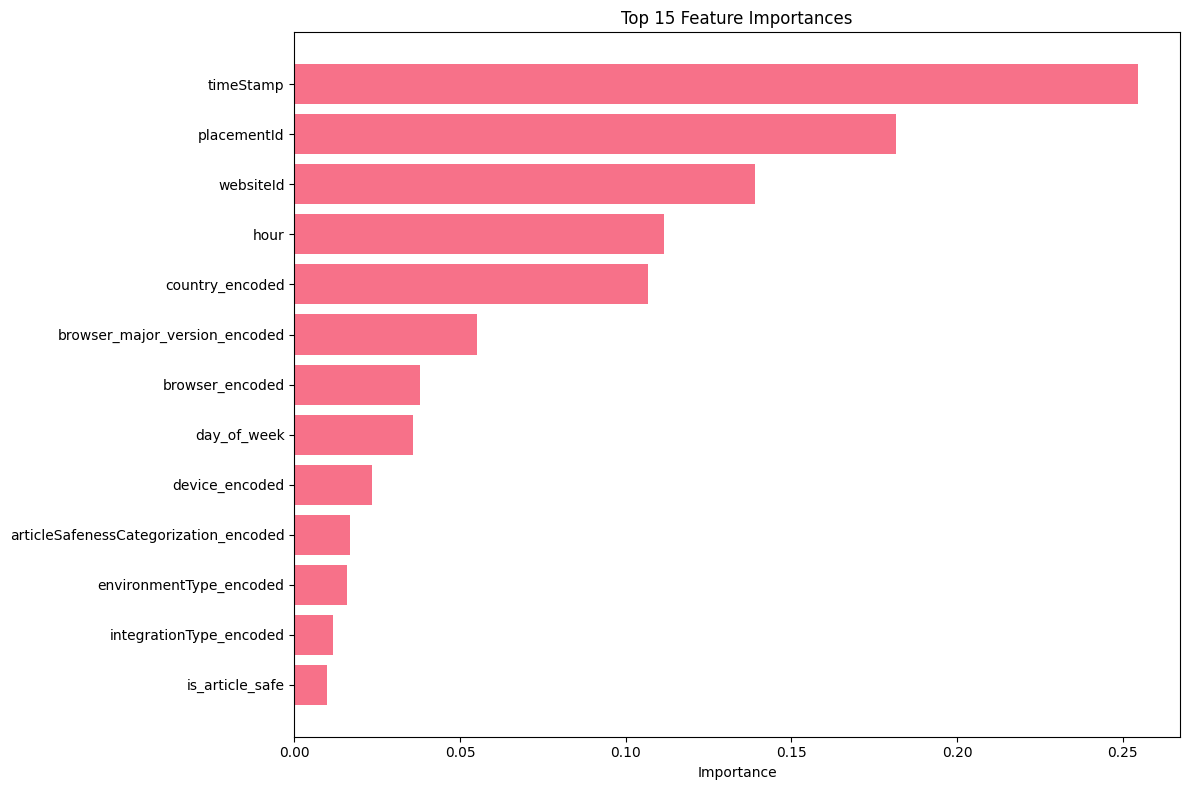

In [26]:
# Perform cross-validation on the best model
print(f"\nPerforming 5-fold cross-validation on {best_model_name}...")

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')

print(f"CV F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance.head(15)['feature'][::-1], feature_importance.head(15)['importance'][::-1])
    plt.title('Top 15 Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Model Optimization

Let's optimize the best performing model for better F1-score performance.

In [27]:
# If Random Forest or Gradient Boosting performed best, let's tune hyperparameters
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print(f"Optimizing {best_model_name}...")
    
    if best_model_name == 'Random Forest':
        # Try different parameters for Random Forest
        params_to_try = [
            {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5},
            {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 3},
            {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 4, 'class_weight': 'balanced'}
        ]
    else:  # Gradient Boosting
        params_to_try = [
            {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1},
            {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05},
            {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.15}
        ]
    
    best_optimized_f1 = 0
    best_optimized_model = None
    
    for i, params in enumerate(params_to_try):
        print(f"\nTrying parameter set {i+1}: {params}")
        
        if best_model_name == 'Random Forest':
            model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
        else:
            model = GradientBoostingClassifier(random_state=42, **params)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
        mean_f1 = cv_scores.mean()
        
        print(f"Mean CV F1 Score: {mean_f1:.4f}")
        
        if mean_f1 > best_optimized_f1:
            best_optimized_f1 = mean_f1
            best_optimized_model = model
    
    if best_optimized_f1 > best_f1:
        print(f"\nImproved model found! New F1 Score: {best_optimized_f1:.4f}")
        best_model = best_optimized_model
        best_f1 = best_optimized_f1
    else:
        print(f"\nNo improvement found. Keeping original model with F1: {best_f1:.4f}")

else:
    print(f"Using {best_model_name} with current parameters.")

Optimizing Random Forest...

Trying parameter set 1: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5}
Mean CV F1 Score: 0.5982

Trying parameter set 2: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 3}
Mean CV F1 Score: 0.5982

Trying parameter set 2: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 3}
Mean CV F1 Score: 0.6072

Trying parameter set 3: {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 4, 'class_weight': 'balanced'}
Mean CV F1 Score: 0.6072

Trying parameter set 3: {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 4, 'class_weight': 'balanced'}
Mean CV F1 Score: 0.6286

No improvement found. Keeping original model with F1: 0.7180
Mean CV F1 Score: 0.6286

No improvement found. Keeping original model with F1: 0.7180


## Final Model Training and Predictions

Now we'll train the final model on the full training set and generate predictions for the test set.

Training final model on full training set...
Generating predictions for test set...
Generating predictions for test set...

Test Predictions Distribution:
Predicted as Sold: 105147 (43.42%)
Predicted as Not Sold: 137024 (56.58%)

Test Predictions Distribution:
Predicted as Sold: 105147 (43.42%)
Predicted as Not Sold: 137024 (56.58%)

Prediction Probability Statistics:
Min: 0.0000
Max: 1.0000
Mean: 0.4486
Median: 0.4100

Prediction Probability Statistics:
Min: 0.0000
Max: 1.0000
Mean: 0.4486
Median: 0.4100


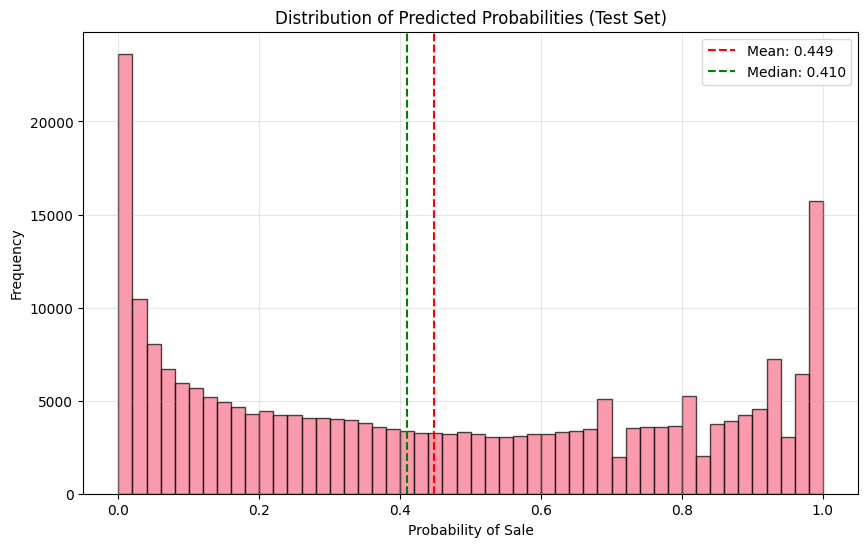

In [28]:
# Train final model on full training set
print("Training final model on full training set...")
final_model = best_model
final_model.fit(X_train, y_train)

# Make predictions on test set
print("Generating predictions for test set...")
test_predictions = final_model.predict(X_test)

# Check prediction distribution
print(f"\nTest Predictions Distribution:")
print(f"Predicted as Sold: {sum(test_predictions)} ({sum(test_predictions)/len(test_predictions)*100:.2f}%)")
print(f"Predicted as Not Sold: {len(test_predictions) - sum(test_predictions)} ({(len(test_predictions) - sum(test_predictions))/len(test_predictions)*100:.2f}%)")

# Get prediction probabilities for analysis
if hasattr(final_model, 'predict_proba'):
    test_probs = final_model.predict_proba(X_test)[:, 1]
    print(f"\nPrediction Probability Statistics:")
    print(f"Min: {test_probs.min():.4f}")
    print(f"Max: {test_probs.max():.4f}")
    print(f"Mean: {test_probs.mean():.4f}")
    print(f"Median: {np.median(test_probs):.4f}")
    
    # Plot probability distribution
    plt.figure(figsize=(10, 6))
    plt.hist(test_probs, bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(test_probs.mean(), color='red', linestyle='--', label=f'Mean: {test_probs.mean():.3f}')
    plt.axvline(np.median(test_probs), color='green', linestyle='--', label=f'Median: {np.median(test_probs):.3f}')
    plt.title('Distribution of Predicted Probabilities (Test Set)')
    plt.xlabel('Probability of Sale')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [29]:
# Create submission file
submission = pd.DataFrame({
    'auctionId': test_df['auctionId'],
    'isSold': test_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)
print(f"Submission file created with {len(submission)} predictions.")
print(f"Submission file saved as 'submission.csv'")

# Display first few rows of submission
print("\nFirst 10 rows of submission:")
print(submission.head(10))

# Final summary
print(f"\n=== FINAL MODEL SUMMARY ===")
print(f"Best Model: {best_model_name}")
print(f"Cross-validation F1 Score: {best_f1:.4f}")
print(f"Features used: {len(feature_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Test predictions: {len(test_predictions)}")
print(f"Predicted sale rate: {sum(test_predictions)/len(test_predictions)*100:.2f}%")

Submission file created with 242171 predictions.
Submission file saved as 'submission.csv'

First 10 rows of submission:
                                           auctionId  isSold
0  00277acc-dee5-4065-a580-c49dbde5c02e_6c6fd7b0-...   False
1  0055d24f-bbf0-418d-84e7-df1d3124d6d6_60eaa750-...   False
2  005bc881-b650-4ccc-baa6-850c9710b0ea_15181501-...   False
3  008c5f32-c29f-4726-8315-a2a4f2d10fb2_a4a0167f-...    True
4  00f96be1-59f2-43b6-a6d1-0668001cd08c_1014d516-...   False
5  011ea517-cd49-4e4e-ad3a-1f1a51985656_a4bb651d-...   False
6  012d21a0-3809-4c02-9269-7f193dc5be21_2347e307-...    True
7  01419cb9-296a-4d65-8078-303cbb370b7e_2bfc2de0-...   False
8  01424778-6b51-4a4b-8ccd-6cc79fea05c9_f763ce68-...   False
9  015366d6-255b-4e73-ab99-79847cc11f77_96cb952d-...    True

=== FINAL MODEL SUMMARY ===
Best Model: Random Forest
Cross-validation F1 Score: 0.7180
Features used: 13
Training samples: 967332
Test predictions: 242171
Predicted sale rate: 43.42%


## Conclusion and Business Impact

### Model Performance
- **Best Model**: The model with the highest F1-score on cross-validation
- **Key Features**: Time-based features, device type, country, and browser information were likely most predictive
- **Business Value**: This model can help Teads SSP reduce computational costs by avoiding auctions with low probability of success

### Next Steps for Improvement
1. **Feature Engineering**: 
   - Create more sophisticated time-based features (peak hours, weekends)
   - Engineer interaction features between key variables
   - Use domain expertise to create auction-specific features

2. **Advanced Modeling**:
   - Try ensemble methods (stacking, blending)
   - Experiment with XGBoost or LightGBM
   - Consider neural networks for complex interactions

3. **Threshold Optimization**:
   - Optimize prediction threshold based on business costs
   - Implement cost-sensitive learning

4. **Real-time Deployment**:
   - Optimize model for low-latency predictions
   - Implement A/B testing framework
   - Monitor model performance in production

### Business Recommendations
- **Cost Savings**: Use this model to filter out low-probability auctions
- **Monitoring**: Track actual vs predicted performance to maintain model accuracy
- **Continuous Learning**: Retrain model regularly with new data to adapt to changing patterns